<a href="https://colab.research.google.com/github/abhishekrs2003/ICT_DSA_2026/blob/main/Supervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Supervised_learning_casestudy

###Importing Libraries

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler, LabelEncoder

# libraries for models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

#libraries for performance evaluvation
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

# libraries for fine tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

###Loading Training data and testing data

In [102]:
# training data file path
train_data_path="/content/drive/MyDrive/DSA Works/Datasets/Training_data.csv"

# testing data file path
test_data_path="/content/drive/MyDrive/DSA Works/Datasets/Testing_data.csv"

In [103]:
# loading training data
customer_df_train = pd.read_csv(train_data_path)
customer_df_train.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [104]:
# loading tesing data
customer_df_test = pd.read_csv(test_data_path)
customer_df_train.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


## Exploratory Data Analysis (EDA) And Data Pre Processing

In [105]:
# information of triaining data
customer_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [106]:
# information of testing data
customer_df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [107]:
# statistical analysis of training data
customer_df_train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [108]:
# statistical analysis of testing data
customer_df_test.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013
std,0.377300,24.322161,30.282693
min,0.000000,0.000000,18.700000
25%,0.000000,8.000000,30.100000
50%,0.000000,27.000000,69.900000
75%,0.000000,54.000000,89.500000
max,1.000000,72.000000,118.600000


In [109]:
# checking for missing values of training data
customer_df_train.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [110]:
# # checking for missing values of testing data
customer_df_test.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [111]:
# checking duplicates for training data
customer_df_train.duplicated().sum()

np.int64(0)

In [112]:
# checking duplicates for testing data
customer_df_test.duplicated().sum()

np.int64(0)

In [113]:
num_cols = customer_df_train.select_dtypes(include=['number']).columns # to get the columns with numerical data
cat_cols = customer_df_train.select_dtypes(include=['object']).columns # to get the columns with catogoecal data

In [114]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [115]:
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [116]:
missing_percent = customer_df_train.isna().sum()/len(customer_df_train)*100 # checking the percentage of missing values
sorted = missing_percent.sort_values(ascending=True)
sorted

,0
customerID,0.000000
SeniorCitizen,0.000000
Partner,0.000000
Dependents,0.000000
PhoneService,0.000000
tenure,0.000000
MultipleLines,0.000000
InternetService,0.000000
StreamingMovies,0.000000
OnlineBackup,0.000000


In [117]:
# Converting TotalCharges to numeric
customer_df_train['TotalCharges'] = pd.to_numeric(customer_df_train['TotalCharges'], errors='coerce')
num_cols = customer_df_train.select_dtypes(include=['number']).columns # to get the columns with numerical data
cat_cols = customer_df_train.select_dtypes(include=['object']).columns # to get the columns with catogoecal data

In [118]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [119]:
# converting total charges in testing data from catogorical col to numeric
customer_df_test['TotalCharges'] = pd.to_numeric(customer_df_test['TotalCharges'], errors='coerce')

In [120]:
customer_df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [121]:
# since the total charges have been converted it may have missing values now in testing data
customer_df_test.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [122]:
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

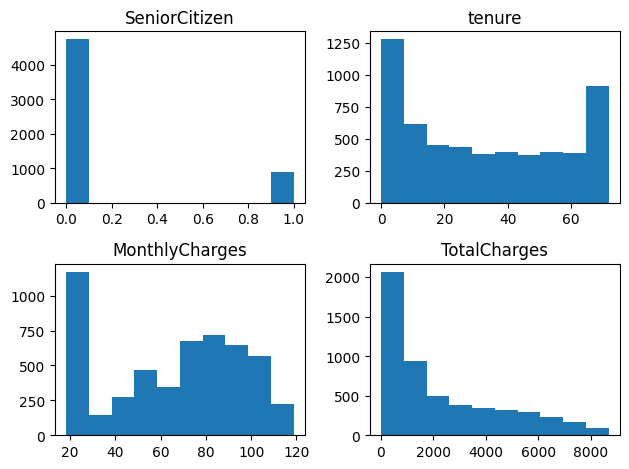

In [123]:
# using iterative method to plot all histograms of numerical columns in training data
for i, col in enumerate(num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(customer_df_train[col])
  plt.title(col)

plt.tight_layout()
plt.show()

### Handling missing values

In [124]:
# calculating the median of test data to replace it with the missing values in testing data
train_data_median = customer_df_train['TotalCharges'].median()

In [125]:
# replacing missing values with median because distribution is skewed
customer_df_train['MonthlyCharges'].fillna(customer_df_train['MonthlyCharges'].median(), inplace=True)
customer_df_train['TotalCharges'].fillna(customer_df_train['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_13914/1631829598.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df_train['MonthlyCharges'].fillna(customer_df_train['MonthlyCharges'].median(), inplace=True)
/tmp/ipykernel_13914/1631829598.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [126]:
# replacing the missng values in testing data with medain from training data
customer_df_test['TotalCharges'].fillna(train_data_median, inplace=True)

/tmp/ipykernel_13914/52796403.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df_test['TotalCharges'].fillna(train_data_median, inplace=True)


In [127]:
customer_df_train.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [128]:
customer_df_test.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [129]:
# replacing catogorical column null values with mode
customer_df_train['gender'].fillna(customer_df_train['gender'].mode()[0],inplace=True)

customer_df_train['OnlineSecurity'].fillna(customer_df_train['OnlineSecurity'].mode()[0],inplace=True)


/tmp/ipykernel_13914/3276438822.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df_train['gender'].fillna(customer_df_train['gender'].mode()[0],inplace=True)
/tmp/ipykernel_13914/3276438822.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df

In [130]:
customer_df_train.isna().sum() # missing values replaced

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


###Handling outliers

In [131]:
customer_df_train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,32.606851,65.490034,2238.250728
std,0.366401,24.614976,29.020760,2216.294428
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,44.000000,446.062500
50%,0.000000,29.000000,70.650000,1396.450000
75%,0.000000,56.000000,89.100000,3590.537500
max,1.000000,72.000000,118.750000,8684.800000


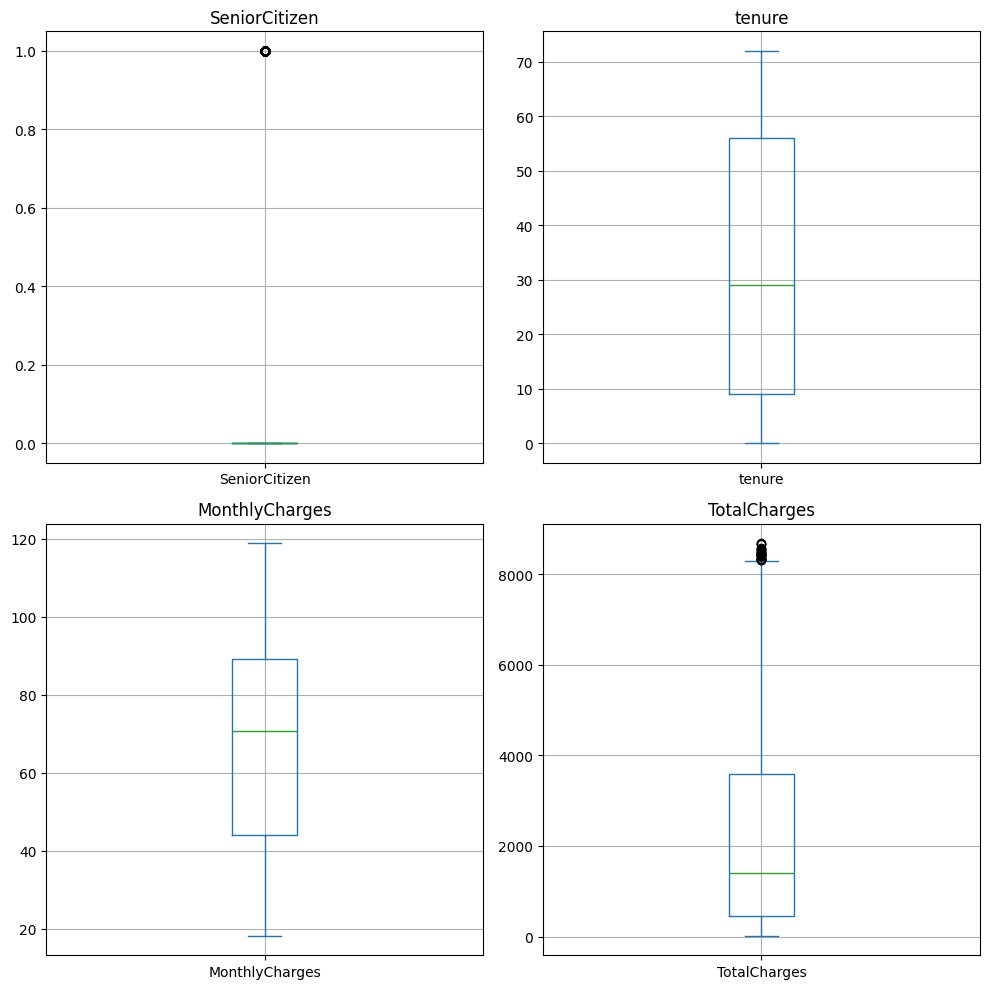

In [132]:
# ploting box plot to identify outliers
plt.figure(figsize=(10,10))
for i, col in enumerate(num_cols,1):
  plt.subplot(2,2,i)
  customer_df_train[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [133]:
Q1 = customer_df_train[num_cols].quantile(0.25)
Q3 = customer_df_train[num_cols].quantile(0.75)
IQR = Q3-Q1


upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((customer_df_train[num_cols] > upper_limit) | (customer_df_train[num_cols] < lower_limit)).any(axis=1)

outliers_df = customer_df_train[outliers]

outlier_percentage = len(outliers_df) * 100/ len(customer_df_train)

print("percentage fo outliers in the dataframe :", outlier_percentage)

percentage fo outliers in the dataframe : 16.311679091231806


In [134]:
outliers_count = ((customer_df_train[num_cols] > upper_limit) | (customer_df_train[num_cols] < lower_limit)).mean()*100

In [135]:
outliers_count # outlier percentage is very small for total charges and senior citizen is binary data

,0
SeniorCitizen,15.974441
tenure,0.000000
MonthlyCharges,0.000000
TotalCharges,0.425985


###Identifying corelation

In [136]:
# corealtion matrix of training data
corr_matrix = customer_df_train[num_cols].corr(method='pearson')
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.022672,0.205024,0.101343
tenure,0.022672,1.000000,0.232216,0.796983
MonthlyCharges,0.205024,0.232216,1.000000,0.606911
TotalCharges,0.101343,0.796983,0.606911,1.000000


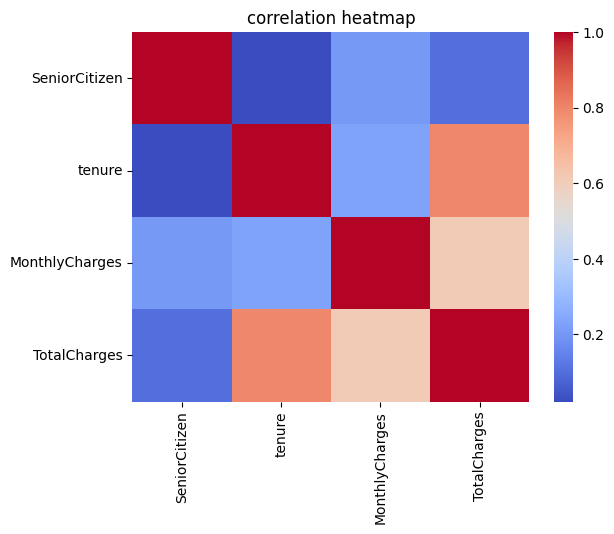

In [137]:
# correltion heatmap of training data
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [138]:
# removing column from training data
customer_df_train.drop(['customerID'], axis=1, inplace=True) # removing customerID as it is an identifier not a valid contributor
customer_df_train.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,Female,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No


In [139]:
# removing column from testing data
customer_df_test.drop(['customerID'], axis=1, inplace=True)
customer_df_test.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.30,No
1,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No


###Data Tranformation

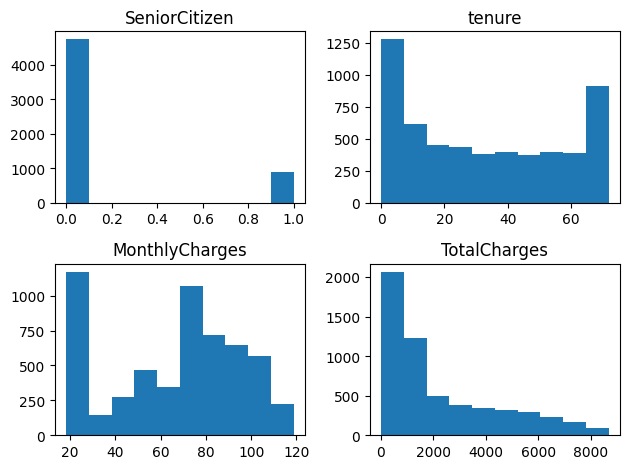

In [140]:
for i, col in enumerate(num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(customer_df_train[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [141]:
customer_df_train.describe() # before scaling --training data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,32.606851,65.490034,2238.250728
std,0.366401,24.614976,29.020760,2216.294428
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,44.000000,446.062500
50%,0.000000,29.000000,70.650000,1396.450000
75%,0.000000,56.000000,89.100000,3590.537500
max,1.000000,72.000000,118.750000,8684.800000


In [142]:
customer_df_test.describe() # before scaling --testing data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013,2214.263272
std,0.377300,24.322161,30.282693,2242.047466
min,0.000000,0.000000,18.700000,18.800000
25%,0.000000,8.000000,30.100000,360.100000
50%,0.000000,27.000000,69.900000,1358.850000
75%,0.000000,54.000000,89.500000,3673.600000
max,1.000000,72.000000,118.600000,8547.150000


In [143]:
# scaling training data

min_max_scaler = MinMaxScaler() # using min- max scaler because the distribution is skewed
customer_df_train[['tenure','MonthlyCharges','TotalCharges']] = min_max_scaler.fit_transform(customer_df_train[['tenure','MonthlyCharges','TotalCharges']])
# senior ciitizen column is not skewed as it have binary values

In [144]:
# scaling testing data
# using same scaler from the training data
customer_df_test[['tenure','MonthlyCharges','TotalCharges']] = min_max_scaler.fit_transform(customer_df_test[['tenure','MonthlyCharges','TotalCharges']])


In [145]:
customer_df_train.describe() # After scaling -- training data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,0.452873,0.470050,0.256106
std,0.366401,0.341875,0.288764,0.255747
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.125000,0.256219,0.049298
50%,0.000000,0.402778,0.521393,0.158967
75%,0.000000,0.777778,0.704975,0.412152
max,1.000000,1.000000,1.000000,1.000000


In [146]:
customer_df_test.describe() # After scaling -- testing data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000,1409.000000
mean,0.171753,0.436509,0.452433,0.257431
std,0.377300,0.337808,0.303130,0.262893
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.111111,0.114114,0.040019
50%,0.000000,0.375000,0.512513,0.157129
75%,0.000000,0.750000,0.708709,0.428547
max,1.000000,1.000000,1.000000,1.000000


In [147]:
# corelation after scaling
corr_matrix = customer_df_train[num_cols].corr(method='pearson')
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.022672,0.205024,0.101343
tenure,0.022672,1.000000,0.232216,0.796983
MonthlyCharges,0.205024,0.232216,1.000000,0.606911
TotalCharges,0.101343,0.796983,0.606911,1.000000


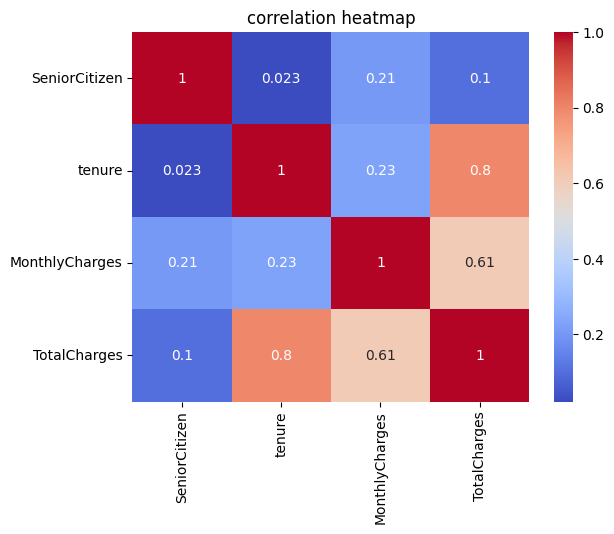

In [148]:
# ploting a heat map to visualize correlation after scaling
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

### Encoding

In [149]:
customer_df_train.head(2) # before encoding

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,0.486111,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0.024876,0.078653,No
1,Female,0,No,No,0.388889,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,0.174129,0.108765,No


In [150]:
customer_df_train['PaperlessBilling'].unique()

array(['No', 'Yes'], dtype=object)

In [151]:
customer_df_train['Partner'].unique()

array(['No', 'Yes'], dtype=object)

In [152]:
customer_df_train['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [153]:
customer_df_train['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [154]:
customer_df_train['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [155]:
customer_df_train['MultipleLines'].unique()

array(['No', 'No phone service', 'Yes'], dtype=object)

In [156]:
customer_df_train['InternetService'].unique()

array(['No', 'DSL', 'Fiber optic'], dtype=object)

In [157]:
customer_df_train['OnlineSecurity'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [158]:
customer_df_train['OnlineBackup'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [159]:
customer_df_train['DeviceProtection'].unique()

array(['No internet service', 'Yes', 'No'], dtype=object)

In [160]:
customer_df_train['TechSupport'].unique()

array(['No internet service', 'Yes', 'No'], dtype=object)

In [161]:
customer_df_train['StreamingTV'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [162]:
customer_df_train['StreamingMovies'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [163]:
customer_df_train['Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [164]:
customer_df_train['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [165]:
# churn is the target therefore label encoder
# binary data - PaperlessBilling, Partner, gender, Dependents, PhoneService -- label encoding
# one hot encoding - MultipleLines, InternetService	, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod

In [166]:
# doing label encoding in above mentioned columns in training data

label_encoder = LabelEncoder()

customer_df_train['Churn'] = label_encoder.fit_transform(customer_df_train['Churn'])
customer_df_train['PaperlessBilling'] = label_encoder.fit_transform(customer_df_train['PaperlessBilling'])
customer_df_train['Partner'] = label_encoder.fit_transform(customer_df_train['Partner'])
customer_df_train['gender'] = label_encoder.fit_transform(customer_df_train['gender'])
customer_df_train['Dependents'] = label_encoder.fit_transform(customer_df_train['Dependents'])
customer_df_train['PhoneService'] = label_encoder.fit_transform(customer_df_train['PhoneService'])

In [167]:
# applying one hot encoding in above mentioned columns in training data

customer_df_train = pd.get_dummies(customer_df_train, columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'], dtype=int)

In [168]:
customer_df_train.head(5) # training data after encoding

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,0.486111,1,0,0.024876,0.078653,0,...,0,1,0,0,1,0,0,0,0,1
1,0,0,0,0,0.388889,0,1,0.174129,0.108765,0,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,0.777778,1,0,0.799502,0.641845,0,...,0,0,1,1,0,0,0,0,1,0
3,1,0,1,0,0.541667,1,1,0.021891,0.088986,0,...,0,1,0,0,0,1,1,0,0,0
4,0,0,1,1,0.597222,0,1,0.328358,0.246107,0,...,1,0,0,0,1,0,1,0,0,0


In [169]:
# label Encoding  for testing data
customer_df_test['Churn'] = label_encoder.fit_transform(customer_df_test['Churn'])
customer_df_test['PaperlessBilling'] = label_encoder.fit_transform(customer_df_test['PaperlessBilling'])
customer_df_test['Partner'] = label_encoder.fit_transform(customer_df_test['Partner'])
customer_df_test['gender'] = label_encoder.fit_transform(customer_df_test['gender'])
customer_df_test['Dependents'] = label_encoder.fit_transform(customer_df_test['Dependents'])
customer_df_test['PhoneService'] = label_encoder.fit_transform(customer_df_test['PhoneService'])

In [170]:
# one hot encoding in testing data

customer_df_test = pd.get_dummies(customer_df_test, columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'], dtype=int)

In [171]:
customer_df_test.head(5) # testing data after encoding

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,0.555556,1,1,0.625626,0.383837,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,1,0,0.166667,1,0,0.602102,0.100600,0,...,0,0,1,0,1,0,0,0,1,0
2,1,0,0,0,0.597222,1,1,0.813814,0.491625,1,...,0,0,1,0,1,0,0,0,1,0
3,1,0,0,0,1.000000,1,1,0.995996,1.000000,0,...,0,0,1,0,0,1,0,0,1,0
4,0,0,0,0,0.138889,0,0,0.175676,0.041649,0,...,1,0,0,1,0,0,0,0,1,0


### Feature Engineering

In [172]:
# This estimates how much revenue a customer has generated.

customer_df_train['CustomerLifetimeValue'] = (

    customer_df_train['tenure'] *
    customer_df_train['MonthlyCharges']
)

customer_df_test['CustomerLifetimeValue'] = (
    customer_df_test['tenure'] *
    customer_df_test['MonthlyCharges']
)

In [173]:
customer_df_train.head(5) # training data after adding new feature

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue
0,0,0,0,0,0.486111,1,0,0.024876,0.078653,0,...,1,0,0,1,0,0,0,0,1,0.012092
1,0,0,0,0,0.388889,0,1,0.174129,0.108765,0,...,0,0,1,0,0,0,0,0,1,0.067717
2,1,0,0,0,0.777778,1,0,0.799502,0.641845,0,...,0,1,1,0,0,0,0,1,0,0.621835
3,1,0,1,0,0.541667,1,1,0.021891,0.088986,0,...,1,0,0,0,1,1,0,0,0,0.011857
4,0,0,1,1,0.597222,0,1,0.328358,0.246107,0,...,0,0,0,1,0,1,0,0,0,0.196103


In [174]:
customer_df_test.head(5) # testing data after adding new feature

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue
0,1,0,1,1,0.555556,1,1,0.625626,0.383837,0,...,0,0,1,0,0,0,0,1,0,0.347570
1,0,0,1,0,0.166667,1,0,0.602102,0.100600,0,...,0,1,0,1,0,0,0,1,0,0.100350
2,1,0,0,0,0.597222,1,1,0.813814,0.491625,1,...,0,1,0,1,0,0,0,1,0,0.486028
3,1,0,0,0,1.000000,1,1,0.995996,1.000000,0,...,0,1,0,0,1,0,0,1,0,0.995996
4,0,0,0,0,0.138889,0,0,0.175676,0.041649,0,...,0,0,1,0,0,0,0,1,0,0.024399


### Data spliting

In [175]:
X_train = customer_df_train.drop('Churn', axis=1)

y_train = customer_df_train['Churn']

In [176]:
X_test = customer_df_test.drop('Churn', axis=1)

y_test = customer_df_test['Churn']

### Model Development

In [177]:
# Logistic regression

# Initialising the model
logreg_model = LogisticRegression()
# training the model
logreg_model.fit(X_train,y_train)
# prediction using the trained model
y_pred_logistic_reg = logreg_model.predict(X_test)

In [178]:
# Model evaluavation

logreg_accuracy = accuracy_score(y_test, y_pred_logistic_reg)
logreg_conf_matrix = confusion_matrix(y_test, y_pred_logistic_reg)
log_reg_precision = precision_score(y_test, y_pred_logistic_reg)
log_reg_recall = recall_score(y_test, y_pred_logistic_reg)
log_reg_f1score = f1_score(y_test, y_pred_logistic_reg)

print(f"Accuracy is: {logreg_accuracy}")
print(f"confusion matrix is :{logreg_conf_matrix}")
print(f" Precision score is:{log_reg_precision}")
print(f" Recall score is:{log_reg_recall}")
print(f" f1 score is:{log_reg_f1score}")

Accuracy is: 0.8197303051809794
confusion matrix is :[[949  95]
 [159 206]]
 Precision score is:0.6843853820598007
 Recall score is:0.5643835616438356
 f1 score is:0.6186186186186187


In [179]:
# KNN model

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train,y_train)
y_pred_knn = knn_model.predict(X_test)

In [180]:
# KNN evaluvation
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_conf_matrix = confusion_matrix(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1score = f1_score(y_test, y_pred_knn)

print(f"Accuracy of knn is: {knn_accuracy}")
print(f"confusion matrix is :{knn_conf_matrix}")
print(f" Precision score is:{knn_precision}")
print(f" Recall score is:{knn_recall}")
print(f" f1 score is:{knn_f1score}")

Accuracy of knn is: 0.7473385379701917
confusion matrix is :[[867 177]
 [179 186]]
 Precision score is:0.512396694214876
 Recall score is:0.5095890410958904
 f1 score is:0.510989010989011


In [181]:
# Naive bayes model

naivebs_model = GaussianNB()
naivebs_model.fit(X_train,y_train)
y_pred_naivebs = naivebs_model.predict(X_test)

In [182]:
nb_accuracy = accuracy_score(y_test, y_pred_naivebs)
nb_conf_matrix = confusion_matrix(y_test, y_pred_naivebs)
nb_precision = precision_score(y_test, y_pred_naivebs)
nb_recall = recall_score(y_test, y_pred_naivebs)
nb_f1score = f1_score(y_test, y_pred_naivebs)

print(f"Accuracy of naive bayes is: {nb_accuracy}")
print(f"confusion matrix is :{nb_conf_matrix}")
print(f" Precision score is:{nb_precision}")
print(f" Recall score is:{nb_recall}")
print(f" f1 score is:{nb_f1score}")

Accuracy of naive bayes is: 0.6792051100070973
confusion matrix is :[[662 382]
 [ 70 295]]
 Precision score is:0.4357459379615953
 Recall score is:0.8082191780821918
 f1 score is:0.5662188099808061


In [183]:
#SVM Model

svm_model = svm.SVC()
svm_model.fit(X_train,y_train)
y_pred_svm = svm_model.predict(X_test)

In [184]:
svm_accuracy = accuracy_score(y_test,y_pred_svm )
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1score = f1_score(y_test, y_pred_svm)

print(f"Accuracy of SVM is: {svm_accuracy}")
print(f"confusion matrix is :{svm_conf_matrix}")
print(f" Precision score is:{svm_precision}")
print(f" Recall score is:{svm_recall}")
print(f" f1 score is:{svm_f1score}")

Accuracy of SVM is: 0.8069552874378992
confusion matrix is :[[952  92]
 [180 185]]
 Precision score is:0.6678700361010831
 Recall score is:0.5068493150684932
 f1 score is:0.5763239875389408


In [185]:
# Decision Tree
desicion_tree_model = tree.DecisionTreeClassifier()
desicion_tree_model.fit(X_train,y_train)
y_pred_dtree = desicion_tree_model.predict(X_test)

In [186]:
dt_accuracy = accuracy_score(y_test,y_pred_dtree )
dt_conf_matrix = confusion_matrix(y_test, y_pred_dtree)
dt_precision = precision_score(y_test, y_pred_dtree)
dt_recall = recall_score(y_test, y_pred_dtree)
dt_f1score = f1_score(y_test, y_pred_dtree)

print(f"Accuracy of Decision Tree is: {dt_accuracy}")
print(f"confusion matrix is :{dt_conf_matrix}")
print(f" Precision score is:{dt_precision}")
print(f" Recall score is:{dt_recall}")
print(f" Recall score is:{dt_f1score}")

Accuracy of Decision Tree is: 0.7374024130589071
confusion matrix is :[[852 192]
 [178 187]]
 Precision score is:0.49340369393139843
 Recall score is:0.5123287671232877
 Recall score is:0.5026881720430108


In [187]:
# Evaluvation comparison before hyperparameter tuning

result_df = pd.DataFrame()
result_df['Model'] = ['Logistic Regression','KNN','Naive bayes','SVM','Decision Tree']
result_df['Accuracy'] = [logreg_accuracy,knn_accuracy,nb_accuracy,svm_accuracy,dt_accuracy]
result_df['Precision'] = [log_reg_precision,knn_precision,nb_precision,svm_precision,dt_precision]
result_df['Recall'] = [log_reg_recall,knn_recall,nb_recall,svm_recall,dt_recall]
result_df['f1 sccore'] = [log_reg_f1score,knn_f1score,nb_f1score,svm_f1score,dt_recall]



result_df

,Model,Accuracy,Precision,Recall,f1 sccore
0,Logistic Regression,0.819730,0.684385,0.564384,0.618619
1,KNN,0.747339,0.512397,0.509589,0.510989
2,Naive bayes,0.679205,0.435746,0.808219,0.566219
3,SVM,0.806955,0.667870,0.506849,0.576324
4,Decision Tree,0.737402,0.493404,0.512329,0.512329


###Model Fine-Tuning

In [188]:
# Using GridSearchCV to fine tune the logsitic regression model
log_params = {
    'C': [0.01, 0.1, 1, 0.5],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

log_grid = GridSearchCV(
    LogisticRegression(),
    param_grid=log_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print("Best Parameters:", log_grid.best_params_)
print("Best F1 Score:", log_grid.best_score_)

tuned_log_model = log_grid.best_estimator_

Best Parameters: {'C': 0.5, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score: 0.6333642476904786


In [189]:
# prediction using fine tuned logistic regression model
y_pred_log_tuned = tuned_log_model.predict(X_test)

In [190]:
# performance evaluvation of fine tuned logistic regressoin model
logreg_accuracy_tuned = accuracy_score(y_test, y_pred_log_tuned)
logreg_conf_matrix_tuned = confusion_matrix(y_test, y_pred_log_tuned)
log_reg_precision_tuned = precision_score(y_test, y_pred_log_tuned)
log_reg_recall_tuned = recall_score(y_test, y_pred_log_tuned)
log_reg_f1score_tuned = f1_score(y_test, y_pred_log_tuned)

print(f"Accuracy is: {logreg_accuracy_tuned}")
print(f"confusion matrix is :{logreg_conf_matrix_tuned}")
print(f" Precision score is:{log_reg_precision_tuned}")
print(f" Recall score is:{log_reg_recall_tuned}")
print(f" f1 score is:{log_reg_f1score_tuned}")

Accuracy is: 0.7331440738112136
confusion matrix is :[[749 295]
 [ 81 284]]
 Precision score is:0.4905008635578584
 Recall score is:0.7780821917808219
 f1 score is:0.6016949152542372


In [191]:
# Using GridSearchCV to fine tune the knn model
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best F1 Score:", knn_grid.best_score_)

fine_tuned_knn_model = knn_grid.best_estimator_

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best F1 Score: 0.5737365953965935


In [192]:
# prediction using fine tuned knn model
y_pred_knn_fine_tuned = fine_tuned_knn_model.predict(X_test)

In [193]:
# performance evaluvation of fine tuned knn model
knn_accuracy_tuned = accuracy_score(y_test, y_pred_knn_fine_tuned)
knn_conf_matrix_tuned = confusion_matrix(y_test, y_pred_knn_fine_tuned)
knn_precision_tuned = precision_score(y_test, y_pred_knn_fine_tuned)
knn_recall_tuned = recall_score(y_test, y_pred_knn_fine_tuned)
knn_f1score_tuned = f1_score(y_test, y_pred_knn_fine_tuned)

print(f"Accuracy of knn is: {knn_accuracy_tuned}")
print(f"confusion matrix is :{knn_conf_matrix_tuned}")
print(f" Precision score is:{knn_precision_tuned}")
print(f" Recall score is:{knn_recall_tuned}")
print(f" f1 score is:{knn_f1score_tuned}")

Accuracy of knn is: 0.7856635911994322
confusion matrix is :[[902 142]
 [160 205]]
 Precision score is:0.590778097982709
 Recall score is:0.5616438356164384
 f1 score is:0.5758426966292135


In [194]:
# Using GridSearchCV to fine tune the svm model

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

svm_grid = GridSearchCV(
    svm.SVC(),
    param_grid=svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best F1 Score:", svm_grid.best_score_)

fine_tuned_svm_model = svm_grid.best_estimator_

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best F1 Score: 0.6278300495649489


In [195]:
# prediction using fine tuned svm model
y_pred_svm_fine_tuned = fine_tuned_svm_model.predict(X_test)

In [196]:
# performance evaluvation of fine tuned svm model
svm_accuracy_tuned = accuracy_score(y_test,y_pred_svm_fine_tuned )
svm_conf_matrix_tuned = confusion_matrix(y_test, y_pred_svm_fine_tuned)
svm_precision_tuned = precision_score(y_test, y_pred_svm_fine_tuned)
svm_recall_tuned = recall_score(y_test, y_pred_svm_fine_tuned)
svm_f1score_tuned = f1_score(y_test, y_pred_svm_fine_tuned)

print(f"Accuracy of SVM is: {svm_accuracy_tuned}")
print(f"confusion matrix is :{svm_conf_matrix_tuned}")
print(f" Precision score is:{svm_precision_tuned}")
print(f" Recall score is:{svm_recall_tuned}")
print(f" f1 score is:{svm_f1score_tuned}")

Accuracy of SVM is: 0.7203690560681334
confusion matrix is :[[744 300]
 [ 94 271]]
 Precision score is:0.4746059544658494
 Recall score is:0.7424657534246575
 f1 score is:0.5790598290598291


In [197]:
# Using GridSearchCV to fine tune the decision tree model
dt_params = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    tree.DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best F1 Score:", dt_grid.best_score_)

fine_tuned_dt_model = dt_grid.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best F1 Score: 0.5820902022628268


In [198]:
# prediction using fine tuned Decision tree model
y_pred_dt_fine_tuned = fine_tuned_dt_model.predict(X_test)

In [199]:
# performance evaluvation of fine tuned decision tree model
dt_accuracy_tuned = accuracy_score(y_test,y_pred_dt_fine_tuned )
dt_conf_matrix_tuned = confusion_matrix(y_test, y_pred_dt_fine_tuned)
dt_precision_tuned = precision_score(y_test, y_pred_dt_fine_tuned)
dt_recall_tuned = recall_score(y_test, y_pred_dt_fine_tuned)
dt_f1score_tuned = f1_score(y_test, y_pred_dt_fine_tuned)

print(f"Accuracy of Decision Tree is: {dt_accuracy_tuned}")
print(f"confusion matrix is :{dt_conf_matrix_tuned}")
print(f" Precision score is:{dt_precision_tuned}")
print(f" Recall score is:{dt_recall_tuned}")
print(f" Recall score is:{dt_f1score_tuned}")

Accuracy of Decision Tree is: 0.7892122072391767
confusion matrix is :[[890 154]
 [143 222]]
 Precision score is:0.5904255319148937
 Recall score is:0.6082191780821918
 Recall score is:0.5991902834008097


In [200]:
# Evaluvation comparison after hyperparameter tuning

result_df = pd.DataFrame()
result_df['Model'] = ['Logistic Regression','KNN','Naive bayes','SVM','Decision Tree',
                      'Logistic Regression Hypertuned','KNN Hypertuned','SVM Hypertuned','Decision Tree Hypertuned']
result_df['Accuracy'] = [logreg_accuracy,knn_accuracy,nb_accuracy,svm_accuracy,dt_accuracy,
                         logreg_accuracy_tuned,knn_accuracy_tuned,svm_accuracy_tuned,dt_accuracy_tuned]
result_df['Precision'] = [log_reg_precision,knn_precision,nb_precision,svm_precision,dt_precision,
                          log_reg_precision_tuned,knn_precision_tuned,svm_precision_tuned,dt_precision_tuned]
result_df['Recall'] = [log_reg_recall,knn_recall,nb_recall,svm_recall,dt_recall,
                       log_reg_recall_tuned,knn_recall_tuned,svm_recall_tuned,dt_recall_tuned]
result_df['f1 Score'] = [log_reg_f1score,knn_f1score,nb_f1score,svm_f1score,dt_f1score,
                       log_reg_f1score_tuned,knn_f1score_tuned,svm_f1score_tuned,dt_f1score_tuned]



result_df

,Model,Accuracy,Precision,Recall,f1 Score
0,Logistic Regression,0.819730,0.684385,0.564384,0.618619
1,KNN,0.747339,0.512397,0.509589,0.510989
2,Naive bayes,0.679205,0.435746,0.808219,0.566219
3,SVM,0.806955,0.667870,0.506849,0.576324
4,Decision Tree,0.737402,0.493404,0.512329,0.502688
5,Logistic Regression Hypertuned,0.733144,0.490501,0.778082,0.601695
6,KNN Hypertuned,0.785664,0.590778,0.561644,0.575843
7,SVM Hypertuned,0.720369,0.474606,0.742466,0.579060
8,Decision Tree Hypertuned,0.789212,0.590426,0.608219,0.599190


Since, In churn prediction, Recall is very important because Missing a customer who may churn is costly.

According to the performance metrics highest recall is for naive bayes, but the other parameters are too low

Therefore, Best balanced model is Hypertuned Logistic Regression with:

Recall: 0.780822
Accuracy: 0.733854
F1 Score: 0.603175
